In [1]:
import torch 
from torch.utils.data import Dataset, DataLoader
from pyteomics import mgf
import numpy as np
import logging
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch import optim
import networkx as nx
from collections import deque
from matplotlib import pyplot as plt

from sklearn.metrics import (
    adjusted_mutual_info_score as AMI,
    adjusted_rand_score as ARI,
)
import random
import pandas as pd



<!-- # model input data preparation -->

In [11]:
processed_features = pd.read_hdf("./peptdeepwork/processed_features.h5", key="features")
processed_features


,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
18080635323514663207,-0.066837,1.242110,0.746972,-0.069704,-0.069538,-0.069381,-0.069236,-0.068794,-0.068469,-0.067082,...,-0.172200,2.558338,-0.627303,0.411093,-0.575519,-0.451568,0.0,1.414214,-0.707107,-0.707107
14669807044004538680,-0.066838,-0.170780,0.725590,-0.069411,-0.069283,-0.069105,-0.069019,-0.068531,-0.068232,-0.066787,...,2.475728,0.805907,2.464574,0.843902,2.549063,1.464245,0.0,1.414214,-0.707107,-0.707107
584780176198780664,-0.068232,-0.312673,-0.937530,-0.069779,-0.069715,-0.069576,-0.069496,-0.069076,-0.068841,-0.067493,...,-0.630078,2.273397,0.485894,-0.611832,-0.575519,-0.451568,0.0,-0.707107,-0.707107,1.414214
584780176198780663,-0.067843,-0.312673,-0.633082,-0.069779,-0.069715,-0.069576,-0.069496,-0.069076,-0.068701,-0.067345,...,-0.630078,0.393660,-0.627303,-0.570494,-0.575519,-0.451568,0.0,-0.707107,1.414214,-0.707107
584780176198780662,-0.067066,-0.312673,0.364587,-0.069723,-0.069717,-0.069561,-0.069465,-0.068970,-0.068701,-0.067233,...,0.254574,-0.630680,-0.627303,-0.088796,-0.392081,-0.451568,0.0,1.414214,-0.707107,-0.707107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13956871899653124234,-0.066274,1.248301,0.661997,-0.069714,-0.069602,-0.069369,-0.069210,-0.068717,-0.068419,-0.066961,...,-0.331678,-0.522545,-0.440432,1.165769,1.806516,1.052303,0.0,-0.707107,-0.707107,1.414214
16568467721864459869,-0.063709,1.233154,2.434768,-0.067235,-0.067186,-0.067747,-0.067718,-0.067297,-0.067027,-0.065604,...,-0.630078,-0.630680,-0.627303,0.240429,2.568486,-0.451568,0.0,1.414214,-0.707107,-0.707107
16568467721864459870,-0.065605,1.233154,1.378530,-0.067235,-0.067186,-0.067642,-0.067580,-0.067176,-0.066908,-0.065476,...,-0.630078,-0.630680,-0.627303,2.642928,0.706135,-0.451568,0.0,-0.707107,1.414214,-0.707107
17256412178792009832,-0.063746,0.607052,2.259991,-0.067126,-0.067182,-0.067089,-0.067027,-0.066736,-0.066571,-0.065088,...,2.441639,2.558338,2.448579,2.565412,2.497366,3.718322,0.0,1.414214,-0.707107,-0.707107


In [9]:
# filePath = "./peptdeepwork/feature_vectors_02.hdf"
filePath = "./peptdeepwork/processed_features_01.h5"
feature_vectors = pd.read_hdf( filePath, key="features").dropna()  
feature_vectors


,charge,precursor_mz,rt_pred,mobility_pred,frag_mz_1,frag_mz_2,frag_mz_3,frag_mz_4,frag_mz_5,frag_mz_6,...,frag_intensity_16,frag_intensity_17,frag_intensity_18,frag_intensity_19,frag_intensity_20,frag_intensity_21,frag_intensity_22,frag_intensity_23,frag_intensity_24,frag_intensity_25
18080635323514663207,2,804.918724,0.866920,1.121280,1265.655884,1250.597290,1152.571777,1135.570435,1064.533203,1021.531311,...,0.000000,0.133576,0.000000,0.517990,0.145572,1.000000,0.000000,0.314286,0.000000,0.000000
14669807044004538680,2,804.443223,0.439486,1.115837,1508.810791,1461.773682,1380.715820,1314.705200,1279.668091,1213.657593,...,0.458418,0.993758,0.445864,0.449113,0.987423,0.450479,0.982555,0.447263,0.993822,0.451014
584780176198780664,4,366.939525,0.396560,0.692501,1203.603760,1104.535400,991.451294,920.414185,833.382202,719.339233,...,0.000000,0.000000,0.948053,0.966607,0.000000,0.910649,0.353758,0.000000,0.000000,0.000000
584780176198780663,3,488.916941,0.396560,0.769997,1203.603760,1104.535400,991.451294,920.414185,833.436340,833.382202,...,0.000000,0.000000,0.456596,0.572042,0.000000,0.321209,0.000000,0.012700,0.000000,0.000000
584780176198780662,2,732.871773,0.396560,1.023946,1249.645630,1102.610229,1003.541870,946.520386,920.414185,833.436340,...,0.488808,0.000000,0.000000,0.893223,0.281256,0.000000,0.000000,0.160699,0.058345,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13956871899653124234,4,981.439546,0.868793,1.099650,1257.556885,1197.985718,1162.467163,1156.509155,1126.948608,1062.427368,...,0.441419,0.680362,0.066740,1.000000,0.094870,0.033909,0.059385,0.546154,0.757643,0.354036
16568467721864459869,2,1787.001213,0.864211,1.550897,3312.846680,3199.762695,2502.444336,2388.401367,2289.333008,2192.280029,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.261851,1.000000,0.000000
16568467721864459870,3,1191.669901,0.864211,1.282039,3312.846680,3199.762695,2589.476318,2502.444336,2388.401367,2289.333008,...,0.000000,0.000000,0.636703,0.000000,0.000000,0.000000,0.000000,1.000000,0.407650,0.000000
17256412178792009832,2,1775.371923,0.674800,1.506409,3402.668213,3202.552002,3046.450928,2959.418945,2749.281982,2563.181641,...,0.971223,0.977715,0.973672,0.972494,0.976585,1.000000,0.977472,0.976184,0.977379,0.981660


In [16]:
# feature_vectors[feature_vectors['frag_mz_6'] >1.200277e+07]

In [15]:
# feature_vectors.columns

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify column groups
charge_col = ['charge']
core_numerical_cols = ['precursor_mz', 'rt_pred', 'mobility_pred']
frag_mz_cols = [f'frag_mz_{i}' for i in range(1, 26)]
frag_intensity_cols = [f'frag_intensity_{i}' for i in range(1, 26)]


# One-hot encode charge
charge_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore',  categories=[[1, 2, 3, 4]]))
])

# Scale core numerical values
core_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

# Scale fragment m/z
frag_mz_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Log + scale fragment intensities
frag_intensity_transformer = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p, validate=False)),
    ('scaler', StandardScaler())
])


from sklearn.compose import make_column_transformer

preprocessor = ColumnTransformer(
    transformers=[
        ('charge', charge_transformer, charge_col),
        ('core', core_transformer, core_numerical_cols),
        # ('frag_mz', frag_mz_transformer, frag_mz_cols),
        ('frag_intensity', frag_intensity_transformer, frag_intensity_cols),
    ], remainder='drop')

# Fit and transform
X_processed = preprocessor.fit_transform(feature_vectors)


In [6]:
# 1. Get one-hot encoded column names for charge
charge_ohe = preprocessor.named_transformers_['charge'].named_steps['onehot']
charge_feature_names = charge_ohe.get_feature_names_out(charge_col)

# 2. Manually combine all column names in the correct order
final_feature_names = np.concatenate([
    charge_feature_names,          # One-hot encoded charge
    core_numerical_cols,           # Scaled core features
    # frag_mz_cols,                  # Scaled fragment m/z
    frag_intensity_cols            # Log-scaled & normalized intensities
])

# 3. Create DataFrame
X_df = pd.DataFrame(X_processed, columns=final_feature_names, index=feature_vectors.index)
X_df

,charge_1,charge_2,charge_3,charge_4,precursor_mz,rt_pred,mobility_pred,frag_intensity_1,frag_intensity_2,frag_intensity_3,...,frag_intensity_16,frag_intensity_17,frag_intensity_18,frag_intensity_19,frag_intensity_20,frag_intensity_21,frag_intensity_22,frag_intensity_23,frag_intensity_24,frag_intensity_25
18080635323514663207,0.0,1.0,0.0,0.0,0.000108,0.911099,0.481460,-0.201891,-0.495195,0.630178,...,-0.730067,-0.186577,-0.714043,1.089950,-0.126504,2.312156,-0.709024,0.519566,-0.646214,-0.485899
14669807044004538680,0.0,1.0,0.0,0.0,0.000108,0.461883,0.477683,2.614165,1.425960,2.420729,...,0.863543,2.224505,0.867527,0.889516,2.250571,0.910201,2.244985,0.947505,2.335721,1.669441
584780176198780664,0.0,0.0,0.0,1.0,0.000035,0.416769,0.183907,-0.459299,-0.495195,-0.551844,...,-0.730067,-0.721952,2.146328,2.207559,-0.712879,2.112702,0.598313,-0.693880,-0.646214,-0.485899
584780176198780663,0.0,0.0,1.0,0.0,0.000055,0.416769,0.237685,-0.459299,-0.495195,-0.551844,...,-0.730067,-0.721952,0.899249,1.240972,-0.712879,0.502832,-0.709024,-0.637844,-0.646214,-0.485899
584780176198780662,0.0,1.0,0.0,0.0,0.000096,0.416769,0.413915,-0.168975,0.478829,2.074950,...,0.950638,-0.721952,-0.714043,2.043412,0.356460,-0.712753,-0.709024,-0.032209,-0.401167,-0.485899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13956871899653124234,0.0,0.0,0.0,1.0,0.000137,0.913068,0.466450,-0.314506,0.972876,0.094578,...,0.814030,1.494268,-0.436910,2.280236,-0.321822,-0.567229,-0.460023,1.240979,1.790892,1.268942
16568467721864459869,0.0,1.0,0.0,0.0,0.000271,0.908251,0.779594,-0.459299,-0.495195,-0.551844,...,-0.730067,-0.721952,-0.714043,-0.711652,-0.712879,-0.712753,-0.709024,0.338792,2.349089,-0.485899
16568467721864459870,0.0,0.0,1.0,0.0,0.000172,0.908251,0.593019,-0.459299,-0.495195,-0.551844,...,-0.730067,-0.721952,1.399325,-0.711652,-0.712879,-0.712753,-0.709024,2.383753,0.831336,-0.485899
17256412178792009832,0.0,1.0,0.0,0.0,0.000269,0.709188,0.748722,2.581592,3.006613,2.400577,...,2.135979,2.190006,2.202372,2.220461,2.226978,2.312156,2.233904,2.330562,2.299934,3.473975


In [7]:
import pandas as pd
import numpy as np

# Convert to Gray code bits
def decimal_to_gray_bits(x, bit_length):
    if pd.isna(x) or x > 2000:
        return np.array([np.nan] * bit_length)
    scaled = int(round((x - 400) * 100))
    gray = scaled ^ (scaled >> 1)
    return np.array([int(b) for b in f"{gray:0{bit_length}b}"])

def transform_frag_mz_to_gray(df, columns, bit_length):
    gray_code_data = []
    for col in columns:
        col_gray = df[col].apply(lambda x: decimal_to_gray_bits(x, bit_length))
        col_gray_matrix = np.vstack(col_gray.values)
        col_names = [f"{col}_gray_{i}" for i in range(bit_length)]
        gray_code_data.append(pd.DataFrame(col_gray_matrix, columns=col_names, index=df.index))
    return pd.concat(gray_code_data, axis=1)

# Define bit length for values from 400.00 to 2000.00 with 2 decimal precision
bit_length = int(np.ceil(np.log2(160000)))  # 160000 = (2000 - 400) * 100 = 160000
gray_df = transform_frag_mz_to_gray(feature_vectors, frag_mz_cols, bit_length)


# # Example input
# # feature_vectors = pd.read_csv(...)  # your original DataFrame

# frag_mz_cols = [f'frag_mz_{i}' for i in range(1, 26)]
# bit_length = 10  # for values 400–1200

# # def decimal_to_gray_bits(x, bit_length):
# #     x = int(x) - 400  # normalize to 0-based
# #     gray = x ^ (x >> 1)
# #     return np.array(list(f"{gray:0{bit_length}b}"), dtype=int)
# def decimal_to_gray_bits(x, bit_length):
#     try:
#         if np.isnan(x) or x > 2000:
#             return np.array([np.nan] * bit_length)
#         x = int(round(x))
#         x = np.clip(x, 400, 1200)  # keep in reasonable range
#         normalized = x - 400
#         gray = normalized ^ (normalized >> 1)
#         bits = f"{gray:0{bit_length}b}"[-bit_length:]
#         return np.array(list(bits), dtype=float)  # use float to allow NaNs
#     except Exception:
#         return np.array([np.nan] * bit_length)


# def transform_frag_mz_to_gray(df, columns, bit_length):
#     gray_code_data = []

#     for col in columns:
#         col_gray = df[col].apply(lambda x: decimal_to_gray_bits(x, bit_length))
#         col_gray_matrix = np.vstack(col_gray.values)
#         col_names = [f"{col}_gray_{i}" for i in range(bit_length)]
#         gray_code_data.append(pd.DataFrame(col_gray_matrix, columns=col_names, index=df.index))

#     return pd.concat(gray_code_data, axis=1)

# # Usage
# gray_df = transform_frag_mz_to_gray(feature_vectors, frag_mz_cols, bit_length)


In [10]:
gray_df

,frag_mz_1_gray_0,frag_mz_1_gray_1,frag_mz_1_gray_2,frag_mz_1_gray_3,frag_mz_1_gray_4,frag_mz_1_gray_5,frag_mz_1_gray_6,frag_mz_1_gray_7,frag_mz_1_gray_8,frag_mz_1_gray_9,...,frag_mz_25_gray_8,frag_mz_25_gray_9,frag_mz_25_gray_10,frag_mz_25_gray_11,frag_mz_25_gray_12,frag_mz_25_gray_13,frag_mz_25_gray_14,frag_mz_25_gray_15,frag_mz_25_gray_16,frag_mz_25_gray_17
18080635323514663207,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0
14669807044004538680,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
584780176198780664,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
584780176198780663,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
584780176198780662,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13956871899653124234,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
16568467721864459869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
16568467721864459870,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
17256412178792009832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0


In [12]:
mz_cols = gray_df.columns
mz_cols[:100]

Index(['frag_mz_1_gray_0', 'frag_mz_1_gray_1', 'frag_mz_1_gray_2',
       'frag_mz_1_gray_3', 'frag_mz_1_gray_4', 'frag_mz_1_gray_5',
       'frag_mz_1_gray_6', 'frag_mz_1_gray_7', 'frag_mz_1_gray_8',
       'frag_mz_1_gray_9', 'frag_mz_1_gray_10', 'frag_mz_1_gray_11',
       'frag_mz_1_gray_12', 'frag_mz_1_gray_13', 'frag_mz_1_gray_14',
       'frag_mz_1_gray_15', 'frag_mz_1_gray_16', 'frag_mz_1_gray_17',
       'frag_mz_2_gray_0', 'frag_mz_2_gray_1', 'frag_mz_2_gray_2',
       'frag_mz_2_gray_3', 'frag_mz_2_gray_4', 'frag_mz_2_gray_5',
       'frag_mz_2_gray_6', 'frag_mz_2_gray_7', 'frag_mz_2_gray_8',
       'frag_mz_2_gray_9', 'frag_mz_2_gray_10', 'frag_mz_2_gray_11',
       'frag_mz_2_gray_12', 'frag_mz_2_gray_13', 'frag_mz_2_gray_14',
       'frag_mz_2_gray_15', 'frag_mz_2_gray_16', 'frag_mz_2_gray_17',
       'frag_mz_3_gray_0', 'frag_mz_3_gray_1', 'frag_mz_3_gray_2',
       'frag_mz_3_gray_3', 'frag_mz_3_gray_4', 'frag_mz_3_gray_5',
       'frag_mz_3_gray_6', 'frag_mz_3_gray_7',

In [14]:

# X_processed.shape
# feature_vectors.shape
# feature_vectors.max()

In [11]:
import pandas as pd

df_combined = pd.concat([X_df, gray_df], axis=1)
df_combined


,charge_1,charge_2,charge_3,charge_4,precursor_mz,rt_pred,mobility_pred,frag_intensity_1,frag_intensity_2,frag_intensity_3,...,frag_mz_25_gray_8,frag_mz_25_gray_9,frag_mz_25_gray_10,frag_mz_25_gray_11,frag_mz_25_gray_12,frag_mz_25_gray_13,frag_mz_25_gray_14,frag_mz_25_gray_15,frag_mz_25_gray_16,frag_mz_25_gray_17
18080635323514663207,0.0,1.0,0.0,0.0,0.000108,0.911099,0.481460,-0.201891,-0.495195,0.630178,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0
14669807044004538680,0.0,1.0,0.0,0.0,0.000108,0.461883,0.477683,2.614165,1.425960,2.420729,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
584780176198780664,0.0,0.0,0.0,1.0,0.000035,0.416769,0.183907,-0.459299,-0.495195,-0.551844,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
584780176198780663,0.0,0.0,1.0,0.0,0.000055,0.416769,0.237685,-0.459299,-0.495195,-0.551844,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
584780176198780662,0.0,1.0,0.0,0.0,0.000096,0.416769,0.413915,-0.168975,0.478829,2.074950,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13956871899653124234,0.0,0.0,0.0,1.0,0.000137,0.913068,0.466450,-0.314506,0.972876,0.094578,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
16568467721864459869,0.0,1.0,0.0,0.0,0.000271,0.908251,0.779594,-0.459299,-0.495195,-0.551844,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
16568467721864459870,0.0,0.0,1.0,0.0,0.000172,0.908251,0.593019,-0.459299,-0.495195,-0.551844,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
17256412178792009832,0.0,1.0,0.0,0.0,0.000269,0.709188,0.748722,2.581592,3.006613,2.400577,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0


In [49]:

from sklearn.preprocessing import MinMaxScaler


# Apply Min-Max Scaling
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(processed_features)

# Convert back to DataFrame if needed
normalized_df = pd.DataFrame(normalized_data, columns=processed_features.columns)
normalized_df


,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
0,0.000114,0.911099,0.492208,0.000070,0.000072,0.000067,0.000068,0.000065,0.000065,0.000060,...,0.145572,1.000000,0.000000,0.314286,0.000000,0.000000,0.0,1.0,0.0,0.0
1,0.000114,0.461883,0.488509,0.000090,0.000090,0.000086,0.000083,0.000083,0.000081,0.000079,...,0.987423,0.450479,0.982555,0.447263,0.993822,0.451014,0.0,1.0,0.0,0.0
2,0.000041,0.416769,0.200823,0.000064,0.000060,0.000054,0.000050,0.000045,0.000039,0.000033,...,0.000000,0.910649,0.353758,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0
3,0.000061,0.416769,0.253486,0.000064,0.000060,0.000054,0.000050,0.000045,0.000049,0.000043,...,0.000000,0.321209,0.000000,0.012700,0.000000,0.000000,0.0,0.0,1.0,0.0
4,0.000102,0.416769,0.426063,0.000068,0.000060,0.000055,0.000052,0.000053,0.000049,0.000050,...,0.281256,0.000000,0.000000,0.160699,0.058345,0.000000,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641908,0.000143,0.913068,0.477509,0.000069,0.000068,0.000068,0.000070,0.000070,0.000068,0.000068,...,0.094870,0.033909,0.059385,0.546154,0.757643,0.354036,0.0,0.0,0.0,1.0
641909,0.000277,0.908251,0.784163,0.000240,0.000235,0.000180,0.000173,0.000167,0.000162,0.000155,...,0.000000,0.000000,0.000000,0.261851,1.000000,0.000000,0.0,1.0,0.0,0.0
641910,0.000178,0.908251,0.601455,0.000240,0.000235,0.000187,0.000182,0.000175,0.000170,0.000163,...,0.000000,0.000000,0.000000,1.000000,0.407650,0.000000,0.0,0.0,1.0,0.0
641911,0.000275,0.709188,0.753930,0.000248,0.000235,0.000225,0.000220,0.000205,0.000193,0.000188,...,0.976585,1.000000,0.977472,0.976184,0.977379,0.981660,0.0,1.0,0.0,0.0


<!-- Get a sample of the normalized data -->

# model input data preparation

In [4]:
# mgf_file_path = "./spectraList.mgf"    
# spectra = list(mgf.read(mgf_file_path))


In [5]:
# traning_spectrum_data = []
# for spectrum in spectra:
#     # seperate to bins and
#     quantized_spectra =bin_spectrum(spectrum["m/z array"], spectrum["intensity array"])
#     traning_spectrum_data.append(quantized_spectra)
    

In [6]:
# traning_spectrum_data

Input Data Encoding

Creating the DBScan


In [7]:
class DBSCANBase:
    def __init__(self, eps, minPts):
        self._eps = eps
        self._minPts = minPts

    def fit(self, X):
        pass

    def score(self, X, y):
        y_pred = self.predict(X)
        return (AMI(y, y_pred), ARI(y, y_pred))

    def predict(self, X):
        pass

In [8]:
class DBSCANGraphBased(DBSCANBase):
    
    def __init__(self, eps, minPts):
        super().__init__(eps, minPts)
    def fit(self, X):
        self._construct_graph(X)
        self._get_clusters()
        self._get_centroids(X)
        self._cluster_outliers(X)

    def predict(self, X):
        y = []
        for x in X:
            distances = {
                label: self._distance(x, centroid)
                for label, centroid in self._centroids.items()
            }
            y.append(min(distances, key=distances.get))
        return y

    def _construct_graph(self, X):
        cardinality = len(X)
        graph = nx.Graph()
        graph.add_nodes_from(
            list(range(cardinality)), is_core=False, visited=False, cluster=None
        )
        for i in range(cardinality):
            for j in range(i + 1, cardinality):
                if self._distance(X[i], X[j]) < self._eps:
                    graph.add_edge(i, j)
            if graph.degree[i] >= self._minPts:
                graph.nodes[i]["is_core"] = True
        self._graph = graph

    def _get_clusters(self):
        cluster_label = 0
        for node in self._graph:
            if not self._graph.nodes[node]["visited"] and self._graph.nodes[node][
                "is_core"
            ]:
                self._graph.nodes[node]["visited"] = True
                self._graph.nodes[node]["cluster"] = cluster_label
                self._bfs_node(node, cluster_label)
                cluster_label += 1
        self._num_clusters = cluster_label

    def _bfs_node(self, source, cluster_label):
        neighbors = self._graph.neighbors
        queue = deque([(source, len(self._graph), neighbors(source))])
        while queue:
            _, depth_now, children = queue[0]
            try:
                child = next(children)
                if not self._graph.nodes[child]["visited"]:
                    self._graph.nodes[child]["visited"] = True
                    self._graph.nodes[child]["cluster"] = cluster_label
                    if depth_now > 1:
                        queue.append((child, depth_now - 1, neighbors(child)))
            except StopIteration:
                queue.popleft()

    def _get_centroids(self, X):
        self._centroids = {}
        for i in range(self._num_clusters):
            X_list = []
            for node in self._graph:
                if self._graph.nodes[node]["cluster"] == i:
                    X_list.append(X[i])
            self._centroids.update({i: np.mean(X_list, axis=0)})

    def _cluster_outliers(self, X):
        for node in self._graph:
            if self._graph.nodes[node]["cluster"] is None:
                self._graph.nodes[node]["cluster"] = self.predict(X[node])

    @staticmethod
    def _distance(p1, p2):
        return np.linalg.norm(p1 - p2)


In [9]:
# traning_spectrum_data = np.array(traning_spectrum_data)
# clusterer = DBSCANGraphBased(0.4, 5)
# clusterer.fit(traning_spectrum_data)
# # ami, ari = clusterer.score(X, y)
# # print(f'AMI: {ami}, ARI: {ari}')
# y_pred = clusterer.predict(traning_spectrum_data)
# best_centroids = np.array(
#     [centroid for centroid in clusterer._centroids.values()]
# )

# plt.scatter(traning_spectrum_data[:,0], traning_spectrum_data[:,1], c=y_pred);
# plt.scatter(best_centroids[:,0], best_centroids[:,1], marker='x', color='red');


In [10]:
# def pari_pectrum(spectra, label):
#     spectra_count = len(spectra)
#     labeled_spectral_pairs =[]
#     for i in range(spectra_count):
#         index1 = random.randint(0,spectra_count)
#         index2 = random.randint(0,spectra_count)
#         # if (label[index1]== label[index2]):
#         #     is_same_label = True
#         # else:
#         #     is_same_label = False
#         # labeled_spectral_pairs.append([spectra[index1], spectra[index2],is_same_label])
#     # return labeled_spectral_pairs

# pari_pectrum(traning_spectrum_data, y_pred)

# Loading the deconvoluted spectra using a dataloader

In [11]:
normalized_df = normalized_df.dropna()  # Remove rows with NaN values
normalized_df.shape

(594273, 57)

In [12]:
def generate_random_samples(df, sample_size):
    # Shuffle the full DataFrame
    shuffled_df =  df.sample(frac=1)
    

    # Split into chunks of sample_size
    for i in range(0, len(shuffled_df), sample_size):
        yield shuffled_df.iloc[i:i + sample_size]



<!-- ## Ploting 3d  -->

In [13]:
def plot_tsne_results(tsne_df, size_multiplier=10, figsize=(12, 8)):
    """
    Visualizes t-SNE results with cluster coloring support and automatic dimensionality handling.
    
    Args:
        tsne_df (pd.DataFrame): DataFrame containing t-SNE coordinates (columns TSNE1, TSNE2...)
        size_multiplier (float): Scaling factor for 4th dimension visualization
        figsize (tuple): Figure size dimensions
    
    Returns:
        matplotlib.figure.Figure: The generated figure object
    """
    # Validate input columns
    tsne_cols = [col for col in tsne_df.columns if col.startswith('TSNE')]
    if not tsne_cols:
        raise ValueError("DataFrame must contain TSNE1, TSNE2... columns")
    n_components = len(tsne_cols)
    if n_components not in [2, 3, 4]:
        raise ValueError("Only 2D, 3D, or 4D t-SNE projections are supported")

    # Configure plot settings
    fig = plt.figure(figsize=figsize)
    color_by_cluster = 'cluster' in tsne_df.columns
    cmap = 'viridis' if color_by_cluster else None
    colors = tsne_df['cluster'] if color_by_cluster else None
    
    # Create appropriate axis
    if n_components >= 3:
        ax = fig.add_subplot(111, projection='3d')
    else:
        ax = fig.gca()

    # Get data for plotting
    xs = tsne_df['TSNE1']
    ys = tsne_df['TSNE2']
    zs = tsne_df['TSNE3'] if n_components >= 3 else None
    
    
    # Additional parameters
    kwargs = {'alpha': 0.7}
    if colors is not None:
        kwargs['c'] = colors
        kwargs['cmap'] = cmap
    
    if n_components == 4:
        # Normalize and scale TSNE4 for point sizes
        sizes = (tsne_df['TSNE4'] - tsne_df['TSNE4'].min() + 0.2) * size_multiplier # here threshold of 0.2 is added to avoid zero size
        kwargs['s'] = sizes
    
    # Create scatter plot based on dimensions
    if n_components >= 3:
        sc = ax.scatter(xs, ys, zs, **kwargs)
    else:
        sc = ax.scatter(xs, ys, **kwargs)

    # Add labels and decorations
    ax.set_xlabel('TSNE1')
    ax.set_ylabel('TSNE2')
    if n_components >= 3:
        ax.set_zlabel('TSNE3')
    
    title = f"{n_components}D t-SNE Projection"
    if color_by_cluster:
        title += " (Colored by Cluster)"
    if n_components == 4:
        title += " (Size = TSNE4)"
    plt.title(title)

    # Add colorbar if using clusters
    if color_by_cluster:
        plt.colorbar(sc, label='Cluster', ax=ax)
    
    # Add legend for size if using 4D
    if n_components == 4:
        size_info = f"Size scale: {size_multiplier}x normalized TSNE4"
        plt.legend(*sc.legend_elements(prop='sizes'), title=size_info)

    plt.grid(True)
    return fig


<!-- to find similar vectors need to reduce the dimensions using tsne -->


In [14]:
sample_size = 10000
sample_df = next(generate_random_samples(normalized_df, sample_size))
sample_df


,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
412577,0.000083,0.822416,0.321738,0.000109,0.000101,0.000066,0.000066,0.000062,0.000064,0.000055,...,0.386365,0.530351,0.076366,0.064359,0.081612,0.000000,0.0,0.0,0.0,1.0
492803,0.000105,0.910453,0.433477,0.000188,0.000186,0.000155,0.000146,0.000140,0.000133,0.000126,...,0.000000,0.000000,0.919518,1.000000,0.157769,0.000000,0.0,0.0,0.0,1.0
303735,0.000027,0.356359,0.166706,0.000050,0.000050,0.000042,0.000031,0.000032,0.000029,0.000026,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0
256794,0.000047,0.454323,0.236540,0.000052,0.000056,0.000046,0.000041,0.000035,0.000036,0.000025,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,0.0
120620,0.000083,0.866107,0.352468,0.000055,0.000050,0.000040,0.000034,0.000028,0.000026,0.000026,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144933,0.000031,0.466777,0.153109,0.000055,0.000048,0.000045,0.000037,0.000033,0.000032,0.000030,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0
443046,0.000138,0.919305,0.541606,0.000082,0.000075,0.000077,0.000074,0.000072,0.000070,0.000067,...,0.207126,0.166526,0.065699,0.177254,0.067000,0.000541,0.0,1.0,0.0,0.0
377648,0.000096,0.594811,0.393808,0.000065,0.000060,0.000054,0.000057,0.000054,0.000053,0.000054,...,0.003983,0.052909,0.086625,0.108686,0.037029,0.105494,0.0,0.0,1.0,0.0
476745,0.000162,0.485188,0.596913,0.000139,0.000137,0.000131,0.000129,0.000125,0.000118,0.000117,...,0.981705,0.982166,0.446288,0.987706,0.984474,0.450254,0.0,1.0,0.0,0.0


In [15]:
# from sklearn.manifold import TSNE

# tsne = TSNE(
#     n_components=4, 
#     method='exact',
#     learning_rate='auto',
#     random_state=43, 
#     perplexity=30,  #perplexity must be less than n_samples
#     n_iter=1000,
#     )
# tsneResult = tsne.fit_transform(sample_df)
# tsne_result=pd.DataFrame(tsneResult,columns=['TSNE1','TSNE2','TSNE3',"TSNE4"])

In [16]:
# tsne_plot_df = tsne_result  # Add cluster column if exists
# plot_tsne_results(tsne_plot_df, size_multiplier=1)
# plt.show()

In [17]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def tsne_and_similarity(row1, row2, similarity_threshold=0.1):
    """
    Reduces two rows to 2D using t-SNE, plots them, and calculates their similarity.
    
    Args:
        row1 (list): First row of data.
        row2 (list): Second row of data.
        similarity_threshold (float): Threshold for determining similarity.

    Returns:
        dict: A dictionary containing reduced coordinates, distance, and similarity status.
    """
    # Combine the two rows into a single dataset
    data = np.array([row1, row2])

    # Apply t-SNE to reduce dimensions to 2
    tsne = TSNE(n_components=2, method='exact', random_state=42, perplexity=1)
    reduced_data = tsne.fit_transform(data)

    # Plot the two points with different colors
    plt.figure(figsize=(6, 6))
    plt.scatter(reduced_data[0, 0], reduced_data[0, 1], color='blue', label='Row 1')
    plt.scatter(reduced_data[1, 0], reduced_data[1, 1], color='red', label='Row 2')
    plt.legend()
    plt.title('t-SNE Projection of Two Rows')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True)
    plt.show()

    # Calculate Euclidean distance between the original rows
    distance = np.linalg.norm(np.array(row1) - np.array(row2))

    # Determine similarity based on the threshold
    similarity = 'Similar' if distance < similarity_threshold else 'Non-Similar'

    return {
        "reduced_coordinates": reduced_data,
        "distance": distance,
        "similarity": similarity
    }

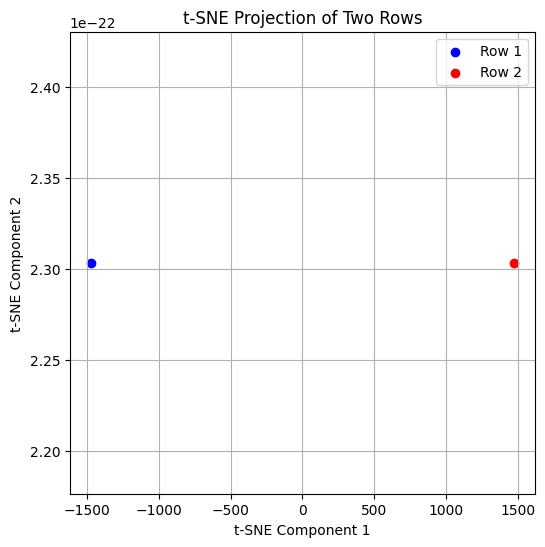

{'reduced_coordinates': array([[-1.4735293e+03,  2.3034420e-22],
       [ 1.4735293e+03,  2.3034420e-22]], dtype=float32), 'distance': 2.259301645764253, 'similarity': 'Non-Similar'}


In [18]:
row1 = sample_df.iloc[3] 
row2 = sample_df.iloc[2] 

result = tsne_and_similarity(row1, row2)
print(result)

<!-- Creating the DBScan -->


In [19]:
class DBSCANBase:
    def __init__(self, eps, minPts):
        self._eps = eps
        self._minPts = minPts

    def fit(self, X):
        pass

    def score(self, X, y):
        y_pred = self.predict(X)
        return (AMI(y, y_pred), ARI(y, y_pred))

    def predict(self, X):
        pass

In [20]:
class DBSCANGraphBased(DBSCANBase):
    
    def __init__(self, eps, minPts):
        super().__init__(eps, minPts)
    def fit(self, X):
        self._construct_graph(X)
        self._get_clusters()
        self._get_centroids(X)
        self._cluster_outliers(X)

    def predict(self, X):
        y = []
        for x in X:
            distances = {
                label: self._distance(x, centroid)
                for label, centroid in self._centroids.items()
            }
            y.append(min(distances, key=distances.get))
        return y

    def _construct_graph(self, X):
        cardinality = len(X)
        graph = nx.Graph()
        graph.add_nodes_from(
            list(range(cardinality)), is_core=False, visited=False, cluster=None
        )
        for i in range(cardinality):
            for j in range(i + 1, cardinality):
                if self._distance(X[i], X[j]) < self._eps:
                    graph.add_edge(i, j)
            if graph.degree[i] >= self._minPts:
                graph.nodes[i]["is_core"] = True
        self._graph = graph

    def _get_clusters(self):
        cluster_label = 0
        for node in self._graph:
            if not self._graph.nodes[node]["visited"] and self._graph.nodes[node][
                "is_core"
            ]:
                self._graph.nodes[node]["visited"] = True
                self._graph.nodes[node]["cluster"] = cluster_label
                self._bfs_node(node, cluster_label)
                cluster_label += 1
        self._num_clusters = cluster_label

    def _bfs_node(self, source, cluster_label):
        neighbors = self._graph.neighbors
        queue = deque([(source, len(self._graph), neighbors(source))])
        while queue:
            _, depth_now, children = queue[0]
            try:
                child = next(children)
                if not self._graph.nodes[child]["visited"]:
                    self._graph.nodes[child]["visited"] = True
                    self._graph.nodes[child]["cluster"] = cluster_label
                    if depth_now > 1:
                        queue.append((child, depth_now - 1, neighbors(child)))
            except StopIteration:
                queue.popleft()

    def _get_centroids(self, X):
        self._centroids = {}
        for i in range(self._num_clusters):
            X_list = []
            for node in self._graph:
                if self._graph.nodes[node]["cluster"] == i:
                    X_list.append(X[i])
            self._centroids.update({i: np.mean(X_list, axis=0)})

    def _cluster_outliers(self, X):
        for node in self._graph:
            if self._graph.nodes[node]["cluster"] is None:
                self._graph.nodes[node]["cluster"] = self.predict(X[node])

    @staticmethod
    def _distance(p1, p2):
        return np.linalg.norm(p1 - p2)


In [21]:
from sklearn.cluster import DBSCAN

def perform_dbscan_clustering(data, eps=1.3, min_samples=4):
    """
    Perform DBSCAN clustering on the given data.

    Args:
        data (pd.DataFrame): The input data to cluster.
        eps (float): Maximum distance between two samples for them to be considered as in the same neighborhood.
        min_samples (int): Minimum number of neighbors (including the point itself) for a point to be considered a core point.

    Returns:
        np.ndarray: Cluster labels for each point in the dataset.
    """
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    cluster_labels = dbscan.fit_predict(data)
    return cluster_labels

# # Example usage
# cluster_labels = perform_dbscan_clustering(sample_df)
# cluster_labels

In [22]:
all_samples = []
cluster_offset = 0  # Start cluster labels from 0

for sample_df in generate_random_samples(normalized_df, sample_size):
    cluster_labels = perform_dbscan_clustering(sample_df)

    # Adjust cluster labels to be globally unique
    adjusted_labels = []
    for label in cluster_labels:
        if label == -1:
            adjusted_labels.append(-1)  # Keep noise label as -1
        else:
            adjusted_labels.append(label + cluster_offset)

    num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    print(f"Number of clusters found: {num_clusters}")

    sample_df['cluster'] = adjusted_labels
    all_samples.append(sample_df)

    # Update offset for next iteration
    cluster_offset += num_clusters

# Combine all sample dataframes into one
final_df = pd.concat(all_samples, ignore_index=True)


Number of clusters found: 8


C:\Users\havin\AppData\Local\Temp\ipykernel_10960\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 9


C:\Users\havin\AppData\Local\Temp\ipykernel_10960\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 9


...

C:\Users\havin\AppData\Local\Temp\ipykernel_10960\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels
C:\Users\havin\AppData\Local\Temp\ipykernel_10960\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 12
Number of clusters found: 9


C:\Users\havin\AppData\Local\Temp\ipykernel_10960\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels
C:\Users\havin\AppData\Local\Temp\ipykernel_10960\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 10
Number of clusters found: 8


C:\Users\havin\AppData\Local\Temp\ipykernel_10960\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels
C:\Users\havin\AppData\Local\Temp\ipykernel_10960\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


In [23]:
# final_df

In [24]:
# Suppose the flag is a string: 'pearson', 'spearman', or 'kendall'
flag = 'spearman'  # you can change this dynamically

# Compute correlation
correlation_matrix = final_df.drop(columns=['cluster']).corr(method=flag)

print(correlation_matrix)


          0             1         2         3         4         5         6   \
0   1.000000  5.927011e-01  0.973257  0.799524  0.800090  0.815905  0.834516   
1   0.592701  1.000000e+00  0.581687  0.586979  0.569554  0.566643  0.568039   
2   0.973257  5.816866e-01  1.000000  0.745663  0.748909  0.766762  0.787062   
3   0.799524  5.869785e-01  0.745663  1.000000  0.987006  0.977031  0.966497   
4   0.800090  5.695543e-01  0.748909  0.987006  1.000000  0.989952  0.979796   
5   0.815905  5.666430e-01  0.766762  0.977031  0.989952  1.000000  0.990670   
6   0.834516  5.680394e-01  0.787062  0.966497  0.979796  0.990670  1.000000   
7   0.850193  5.728223e-01  0.803272  0.957094  0.968263  0.981783  0.990983   
8   0.863915  5.784320e-01  0.817053  0.947900  0.957627  0.970378  0.983004   
9   0.874196  5.857090e-01  0.826651  0.941826  0.949106  0.962092  0.973247   
10  0.881239  5.937520e-01  0.832670  0.937968  0.943610  0.955152  0.966743   
11  0.884726  6.018644e-01  0.834851  0.

In [25]:
# import seaborn as sns
# plt.figure(figsize=(10, 10))
# sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap='coolwarm', square=True)

In [26]:
final_df

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,cluster
0,0.000226,0.792020,0.704743,0.000206,0.000200,0.000195,0.000192,0.000186,0.000176,0.000170,...,1.000000,0.986726,0.990392,0.982559,0.983972,0.0,1.0,0.0,0.0,0
1,0.000147,0.930135,0.444113,0.000069,0.000072,0.000069,0.000067,0.000064,0.000066,0.000067,...,0.424248,0.029439,1.000000,0.061700,0.038382,0.0,0.0,1.0,0.0,1
2,0.000151,0.410465,0.452533,0.000201,0.000197,0.000189,0.000182,0.000176,0.000170,0.000161,...,0.000000,0.000000,0.793363,1.000000,0.000000,0.0,0.0,1.0,0.0,1
3,0.000273,0.928901,0.777274,0.000176,0.000170,0.000163,0.000153,0.000146,0.000081,0.000078,...,0.071914,0.185177,0.232191,0.051093,0.000000,0.0,1.0,0.0,0.0,2
4,0.000175,0.901929,0.661532,0.000145,0.000140,0.000132,0.000124,0.000118,0.000112,0.000102,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594268,0.000036,0.110688,0.203602,0.000024,0.000024,0.000025,0.000020,0.000019,0.000021,0.000019,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,0.0,485
594269,0.000050,0.568079,0.183896,0.000095,0.000090,0.000084,0.000077,0.000071,0.000068,0.000062,...,0.000000,0.003426,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,482
594270,0.000037,0.284761,0.205448,0.000060,0.000055,0.000052,0.000049,0.000046,0.000044,0.000032,...,0.293142,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,482
594271,0.000071,0.389672,0.324464,0.000049,0.000041,0.000039,0.000032,0.000032,0.000029,0.000027,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0,483


In [27]:

cluster_counts = pd.Series(final_df['cluster']).value_counts()
print(cluster_counts)
len(cluster_counts)


cluster
-1      14374
 91      3365
 122     3356
 463     3354
 202     3350
        ...  
 62         3
 227        3
 206        2
 145        2
 462        2
Name: count, Length: 491, dtype: int64


491

In [28]:
# sample_df_with_cluster_labels = sample_df.copy()
# sample_df_with_cluster_labels['cluster'] = cluster_labels
# sample_df_with_cluster_labels

In [29]:

# tsne_result_with_cluster_labels = tsne_result.copy()
# tsne_result_with_cluster_labels['cluster'] = cluster_labels
# tsne_result_with_cluster_labels

In [30]:

# plot_tsne_results(tsne_result_with_cluster_labels, size_multiplier=1)
# plt.show()

<!-- ## Creating Siamese Pairs  -->

<!-- creating siamese pairs and load with a data loader  -->

In [31]:
def calculate_cosine_similarity(vec1, vec2):
    """
    Calculate cosine similarity between two vectors.
    
    Args:
        vec1 (torch.Tensor): First vector.
        vec2 (torch.Tensor): Second vector.
    
    Returns:
        float: Cosine similarity value.
    """
    # Convert rows to tensors and add batch dimension if needed
    vec1 = torch.tensor(vec1.values, dtype=torch.float32)
    vec2 = torch.tensor(vec2.values, dtype=torch.float32)
    
    return F.cosine_similarity(vec1, vec2, dim=0).item()

In [32]:

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset

def create_siamese_pairs(df, pairs_per_cluster=50, test_size=0.2):
    """
    Creates positive/negative pairs for Siamese network training from clustered data
    
    Args:
        df (pd.DataFrame): DataFrame with feature vectors and 'cluster' column
        pairs_per_cluster: Number of pairs to generate per cluster
        test_size: Proportion of data for validation
    
    Returns:
        (train_loader, val_loader): PyTorch DataLoader objects for training
    """
    # Validate input
    if 'cluster' not in df.columns:
        raise ValueError("DataFrame must contain 'cluster' column")
    
    features = df.drop('cluster', axis=1)
    clusters = df['cluster'].values
    unique_clusters = np.unique(clusters)
    
    # Storage for pairs and labels
    pairs = []
    labels = []
    similar_pairs = []
    dissimilar_pairs = []
    
    # Generate pairs for each cluster
    for cluster in unique_clusters:
        print(f"Processing cluster {cluster}...")
        # need to handle clusters of -1 (noise points in DBSCAN)
        if cluster == -1:
            continue
        # Get indices for current cluster
        cluster_indices = np.where(clusters == cluster)[0]
        
        # Skip clusters with < 2 samples
        if len(cluster_indices) < 2:
            continue
            
        # Positive pairs (same cluster)
        count = 0
        for i in range(pairs_per_cluster):
            count += 1
            if( count % 10 == 1):
                print(f"Processed {count} pairs for cluster {cluster}...")    
            
            # Randomly select two different samples from cluster
            similar_try_count = 0
            while True:
                if similar_try_count > 300:
                    print("Too many tries to find a similar pair")
                    break
                similar_try_count += 1
                idx1, idx2 = np.random.choice(cluster_indices, 2, replace=False)
                cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx2])
                if cos_sim > 0.9:
                    print(f"idx1: {idx1}, idx2: {idx2}, cos_sim: {cos_sim}")
                    pairs.append([features.iloc[idx1], features.iloc[idx2]])
                    similar_pairs.append([idx1, idx2])
                    labels.append(0)
                    break
            
            # pairs.append([features[idx1], features[idx2]])
            # labels.append(0)
            
            # Negative pair (different cluster)
            dissimilar_try_count = 0
            while True:
                # Randomly select a sample from the different clusters
                if dissimilar_try_count > 300:
                    print("Too many tries to find a dissimilar pair")
                    break
                dissimilar_try_count += 1

                other_clusters = unique_clusters[unique_clusters != cluster]
                other_cluster = np.random.choice(other_clusters)
                other_indices = np.where(clusters == other_cluster)[0]
                idx3 = np.random.choice(other_indices)
                
                cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx3])
                if cos_sim < 0.1:
                    print(f"idx1: {idx1}, idx3: {idx3}, cos_sim: {cos_sim}")
                    pairs.append([features.iloc[idx1], features.iloc[idx3]])
                    dissimilar_pairs.append([idx1, idx3])
                    labels.append(1)
                    break
                
            # other_clusters = unique_clusters[unique_clusters != cluster]
            # other_cluster = np.random.choice(other_clusters)
            # other_indices = np.where(clusters == other_cluster)[0]
            # idx3 = np.random.choice(other_indices)
            # pairs.append([features[idx1], features[idx3]])
            # labels.append(1)
    
    # Convert to arrays
    pairs = np.array(pairs)
    labels = np.array(labels)
    
    print(f"Total pairs: {len(pairs)}, Total labels: {len(labels)}")
    print(f"Similar pairs: {len(similar_pairs)}, Dissimilar pairs: {len(dissimilar_pairs)}")
    
    
    # Shuffle and split
    indices = np.arange(len(labels))
    np.random.shuffle(indices)
    pairs = pairs[indices]
    labels = labels[indices]
    
    # Split into train/validation
    X_train, X_val, y_train, y_val = train_test_split(
        pairs, labels, test_size=test_size, stratify=labels
    )
    
    # Convert to PyTorch tensors
    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)
    
    print("X_train shape:", X_train.shape)
    print("X_val shape:", X_val.shape)
    print("y_train shape:", y_train.shape)

    # Create DataLoaders
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=100)
    
    return train_loader, val_loader

# Usage example
# train_loader, val_loader = create_siamese_pairs(your_dataframe)



In [33]:
train_loader, val_loader = create_siamese_pairs(final_df)

Processing cluster -1...
Processing cluster 0...
Processed 1 pairs for cluster 0...
idx1: 785, idx2: 7510, cos_sim: 0.951230525970459
idx1: 785, idx3: 27662, cos_sim: 0.09431759268045425
idx1: 34, idx2: 1723, cos_sim: 0.9227522015571594
idx1: 34, idx3: 429346, cos_sim: 0.098262719810009
idx1: 5399, idx2: 387, cos_sim: 0.9665684700012207
idx1: 5399, idx3: 428983, cos_sim: 0.0717785581946373
idx1: 6233, idx2: 6498, cos_sim: 0.9357081055641174
idx1: 6233, idx3: 271459, cos_sim: 0.075294628739357
idx1: 3827, idx2: 7980, cos_sim: 0.931025505065918
idx1: 3827, idx3: 205685, cos_sim: 0.05494960397481918
idx1: 7498, idx2: 8599, cos_sim: 0.9021180272102356
idx1: 7498, idx3: 400745, cos_sim: 0.09973106533288956
idx1: 94, idx2: 9130, cos_sim: 0.934935986995697
idx1: 94, idx3: 424964, cos_sim: 0.050925061106681824
idx1: 3598, idx2: 1185, cos_sim: 0.9469178915023804
idx1: 3598, idx3: 428548, cos_sim: 0.06172764673829079
idx1: 392, idx2: 8512, cos_sim: 0.912878155708313
idx1: 392, idx3: 516586, cos_

<!-- verify siamese pair -->


In [34]:

# from sklearn.model_selection import train_test_split
# import torch.nn.functional as F
# from torch.utils.data import DataLoader, TensorDataset

# def create_siamese_pairs_temp(df, pairs_per_cluster=1000, test_size=0.2):
#     """
#     Creates positive/negative pairs for Siamese network training from clustered data
    
#     Args:
#         df (pd.DataFrame): DataFrame with feature vectors and 'cluster' column
#         pairs_per_cluster: Number of pairs to generate per cluster
#         test_size: Proportion of data for validation
    
#     Returns:
#         (train_loader, val_loader): PyTorch DataLoader objects for training
#     """
#     # Validate input
#     if 'cluster' not in df.columns:
#         raise ValueError("DataFrame must contain 'cluster' column")
    
#     features = df.drop('cluster', axis=1)
#     clusters = df['cluster'].values
#     unique_clusters = np.unique(clusters)
    
#     # Storage for pairs and labels
#     similarPairsIndices = []
#     dissimilarPairsIndices = []
#     pairs = []
#     labels = []
    
#     # Generate pairs for each cluster
#     for cluster in unique_clusters:
#         print(f"Processing cluster {cluster}...")
#         if cluster == -1:
#             continue
#         # Get indices for current cluster
#         cluster_indices = np.where(clusters == cluster)[0]
        
#         # Skip clusters with < 2 samples
#         if len(cluster_indices) < 2:
#             continue
            
#         # Positive pairs (same cluster)
#         count = 0 
#         for i in range(pairs_per_cluster):
#             if(count % 10 ==0):
#                 count += 1
#                 print(f"Processing cluster {cluster}...{count}")
#             # Randomly select two different samples from cluster
#             similar_try_count = 0
#             while True:
#                 if similar_try_count > 300:
#                     print("Too many tries to find a similar pair")
#                     break
#                 similar_try_count += 1
#                 idx1, idx2 = np.random.choice(cluster_indices, 2, replace=False)
#                 cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx2])
#                 if cos_sim > 0.9:
#                     print(f"idx1: {idx1}, idx2: {idx2}, cos_sim: {cos_sim}")
#                     pairs.append([features.iloc[idx1], features.iloc[idx2]])
#                     similarPairsIndices.append([idx1, idx2])
#                     labels.append(0)
#                     break
            
#             # idx1, idx2 = np.random.choice(cluster_indices, 2, replace=False)
#             # cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx2])
            
            
#             # pairs.append([features.iloc[idx1], features.iloc[idx2]])
#             # similarPairsIndices.append([idx1, idx2])
#             # labels.append(0)
            
#             # Negative pair (different cluster)
            
#             dissimilar_try_count = 0
#             while True:
                
#                 if dissimilar_try_count > 300:
#                     print("Too many tries to find a dissimilar pair")
#                     break
#                 dissimilar_try_count += 1

#                 other_clusters = unique_clusters[unique_clusters != cluster]
#                 other_cluster = np.random.choice(other_clusters)
#                 other_indices = np.where(clusters == other_cluster)[0]
#                 idx3 = np.random.choice(other_indices)
                
#                 cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx3])
#                 if cos_sim < 0.4:
#                     print(f"idx1: {idx1}, idx3: {idx3}, cos_sim: {cos_sim}")
#                     pairs.append([features.iloc[idx1], features.iloc[idx3]])
#                     dissimilarPairsIndices.append([idx1, idx3])
#                     labels.append(1)
#                     break
                
#             # other_clusters = unique_clusters[unique_clusters != cluster]
#             # other_cluster = np.random.choice(other_clusters)
#             # other_indices = np.where(clusters == other_cluster)[0]
#             # idx3 = np.random.choice(other_indices)
            
            
#             # print(f"idx1: {idx1}, idx3: {idx3}, cos_sim: {cos_sim}")
#             # pairs.append([features.iloc[idx1], features.iloc[idx3]])
#             # dissimilarPairsIndices.append([idx1, idx3])
#             # labels.append(1)
    
#     # Convert to arrays
#     pairs = np.array(pairs)
#     labels = np.array(labels)
    
#     # Shuffle and split
#     indices = np.arange(len(labels))
#     np.random.shuffle(indices)
#     pairs = pairs[indices]
#     labels = labels[indices]
    
#     return pairs, labels, similarPairsIndices, dissimilarPairsIndices
    
#     # # Split into train/validation
#     # X_train, X_val, y_train, y_val = train_test_split(
#     #     pairs, labels, test_size=test_size, stratify=labels
#     # )
    
#     # # Convert to PyTorch tensors
#     # X_train = torch.FloatTensor(X_train)
#     # X_val = torch.FloatTensor(X_val)
#     # y_train = torch.LongTensor(y_train)
#     # y_val = torch.LongTensor(y_val)
    
#     # # Create DataLoaders
#     # train_dataset = TensorDataset(X_train, y_train)
#     # val_dataset = TensorDataset(X_val, y_val)
    
#     # train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
#     # val_loader = DataLoader(val_dataset, batch_size=100)
    
#     # return train_loader, val_loader

# # Usage example
# # train_loader, val_loader = create_siamese_pairs(your_dataframe)


# pairs, labels, similar, dissimilar  = create_siamese_pairs_temp(sample_df_with_cluster_labels)

# len(similar) +len(dissimilar)
# len(similar) 
# len(dissimilar)

In [35]:
# sample_df_with_cluster_labels.iloc[similar[1000]]

In [36]:
# i = 2000
# plot_tsne_results(tsne_result_with_cluster_labels.iloc[similar[i]], size_multiplier=100)
# calculate_cosine_similarity(sample_df_with_cluster_labels.iloc[similar[i][0]], sample_df_with_cluster_labels.iloc[similar[i][1]])

<!-- # Loading the deconvoluted spectra using a dataloader -->

In [37]:
class SpectrumDataset(Dataset):
    def __init__(self,mgf_file_path, max_peaks=200):
        self.mgf_file_path = mgf_file_path
        self.max_peaks = max_peaks
        self.spectra = list(mgf.read(mgf_file_path))
        
    def __len__(self):
        return len(self.spectra)

    def __getitem__(self, index):
        spectrum = self.spectra[index]
        mz_values = spectrum.get("m/z array", np.array([]))
        intensity_values = spectrum.get("intensity array", np.array([]))
        
        # normalize intensities
        intensity_values = intensity_values / np.max(intensity_values) if intensity_values.size else intensity_values

        return torch.tensor(np.stack(mz_values,intensity_values), axis=1)

In [38]:
class SiamesNetwork(nn.Module):
    def __init__(self, input_dim=57):
        super().__init__()
        
        # Feature extractors
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 16, 3),
            nn.BatchNorm1d(16),
            nn.SELU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 3),
            nn.SELU(),
            nn.AdaptiveAvgPool1d(10)
        )
        
        self.fc_block = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.SELU(),
            nn.Dropout(0.3)
        )
        
        # Fusion layer
        self.final_fc = nn.Linear(32*10 + 32, 30)

    def forward_once(self, x):
        # Spectral features
        conv_out = self.conv_block(x.unsqueeze(1))  # [batch,32,10]
        conv_out = conv_out.flatten(1)  # [batch,320]
        
        # Precursor features
        fc_out = self.fc_block(x)  # [batch,32]
        
        # Concatenate
        combined = torch.cat([conv_out, fc_out], dim=1)
        return self.final_fc(combined)

    
    def forward(self, x1, x2):
        output1 = self.forward_once(x1)
        output2 = self.forward_once(x2)
        return output1, output2


In [39]:

class SiameseNetwork2(nn.Module):

    def __init__(self):
        super(SiameseNetwork2, self).__init__()

        self.fc1_1 = nn.Linear(34, 32)
        # self.fc1_1 = nn.Linear(34, 16)
        # self.fc1_1 = nn.Linear(61, 32)
        # self.fc1_2 = nn.Linear(16, 5)
        self.fc1_2 = nn.Linear(32, 5)

        self.cnn11 = nn.Conv1d(1, 30, 3)
        self.maxpool11 = nn.MaxPool1d(2)
        # self.cnn12 = nn.Conv1d(30, 30, 3)
        # self.maxpool12 = nn.MaxPool1d(6)
        # self.cnn13 = nn.Conv1d(30, 30, 3)
        # self.maxpool13 = nn.MaxPool1d(3)

        self.cnn21 = nn.Conv1d(1, 30, 3)
        self.maxpool21 = nn.MaxPool1d(2)
        self.cnn22 = nn.Conv1d(30, 30, 3)
        self.maxpool22 = nn.MaxPool1d(2)
        # self.cnn23 = nn.Conv1d(30, 30, 3)
        # self.maxpool23 = nn.MaxPool1d(6)
        # self.cnn24 = nn.Conv1d(30, 30, 3)
        # self.maxpool24 = nn.MaxPool1d(3)

        self.fc2 = nn.Linear(25775, 32)
        # self.fc2 = nn.Linear(19775, 32)

    def forward_once(self, preInfo, fragInfo, refSpecInfo):
        preInfo = self.fc1_1(preInfo)
        preInfo = F.selu(preInfo)
        preInfo = self.fc1_2(preInfo)
        preInfo = F.selu(preInfo)
        preInfo = preInfo.view(preInfo.size(0), -1)

        fragInfo = self.cnn21(fragInfo)
        fragInfo = F.selu(fragInfo)
        fragInfo = self.maxpool21(fragInfo)
        fragInfo = F.selu(fragInfo)
        fragInfo = self.cnn22(fragInfo)
        fragInfo = F.selu(fragInfo)
        fragInfo = self.maxpool22(fragInfo)
        fragInfo = F.selu(fragInfo)
        fragInfo = fragInfo.view(fragInfo.size(0), -1)

        refSpecInfo = self.cnn11(refSpecInfo)
        refSpecInfo = F.selu(refSpecInfo)
        refSpecInfo = self.maxpool11(refSpecInfo)
        refSpecInfo = F.selu(refSpecInfo)
        refSpecInfo = refSpecInfo.view(refSpecInfo.size(0), -1)  # Change the shape of the data, -1 means indeterminate, it depends

        output = torch.cat((preInfo, fragInfo, refSpecInfo), 1)
        # output = self.dropout(output)
        output = self.fc2(output)
        # output = F.selu(output)
        return output

    def forward(self, spectrum01, spectrum02):

        spectrum01 = spectrum01.reshape(spectrum01.shape[0], 1, spectrum01.shape[1])
        spectrum02 = spectrum02.reshape(spectrum02.shape[0], 1, spectrum02.shape[1])

        # input1_1 = spectrum01[:, :, :50]
        # input1_2 = spectrum01[:, :, 50:2499]
        # input1_3 = spectrum01[:, :, 2499:]
        #
        # input2_1 = spectrum02[:, :, :50]
        # input2_2 = spectrum02[:, :, 50:2499]
        # input2_3 = spectrum02[:, :, 2499:]

        input1_1 = spectrum01[:, :, :500]
        input1_2 = spectrum01[:, :, 500:2949]
        input1_3 = spectrum01[:, :, 2949:]

        input2_1 = spectrum02[:, :, :500]
        input2_2 = spectrum02[:, :, 500:2949]
        input2_3 = spectrum02[:, :, 2949:]

        # input1_1 = spectrum01[:, :, :100]
        # input1_2 = spectrum01[:, :, 100:2549]
        # input1_3 = spectrum01[:, :, 2549:]
        #
        # input2_1 = spectrum02[:, :, :100]
        # input2_2 = spectrum02[:, :, 100:2549]
        # input2_3 = spectrum02[:, :, 2549:]

        refSpecInfo1, fragInfo1, preInfo1 = input1_3.cuda(), input1_2.cuda(), input1_1.cuda()
        refSpecInfo2, fragInfo2, preInfo2 = input2_3.cuda(), input2_2.cuda(), input2_1.cuda()

        output01 = self.forward_once(refSpecInfo1, fragInfo1, preInfo1)
        output02 = self.forward_once(refSpecInfo2, fragInfo2, preInfo2)

        return output01, output02

In [40]:
# Define the Contrastive Loss Function
class ContrastiveLoss(torch.nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # # Calculate the euclidian distance and calculate the contrastive loss
        # euclidean_distance = F.pairwise_distance(output1, output2, keepdim = True)

        # loss_contrastive = torch.mean((1-label) * torch.pow(euclidean_distance, 2) +
        #                                 (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        # return loss_contrastive
        
        euclidean_distance = F.pairwise_distance(output1, output2)
        euclidean_distance = euclidean_distance.double()
        #print(euclidean_distance)
        label = label.double()
        loss_contrastive = torch.mean(label * euclidean_distance + (1-label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))

        return loss_contrastive



In [41]:
# net =SiamesNetwork()
# lossFunc = ContrastiveLoss()
# optimzer = optim.Adam(net.parameters(), lr = 0.0005)
for batch_idx, (pairs, labels) in enumerate(train_loader):
    print(pairs.shape)
    x1 = pairs[:, 0, :]  # Shape: [batch_size, input_dim]
    x2 = pairs[:, 1, :]  # Shape: [batch_size, input_dim]
    print(x1.shape)
    print(x1.size(0))
    x11 = x1.view(x1.size(0), -1)
    print(x11.shape)
    

    break

torch.Size([100, 2, 57])
torch.Size([100, 57])
100
torch.Size([100, 57])


In [42]:
if __name__ == "__main__":
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Initialize model and move to device
    model = SiamesNetwork().to(device)
    criterion = ContrastiveLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    
    # Add learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        patience=5, 
        factor=0.5, 
        verbose=True
    )
    
    # Training loop
    num_epochs = 200
    best_loss = float('inf')
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        for batch_idx, (pairs, labels) in enumerate(train_loader):
            # Move data to device
            x1 = pairs[:, 0, :].to(device)
            x2 = pairs[:, 1, :].to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            output1, output2 = model(x1, x2)
            loss = criterion(output1, output2, labels)
            loss.backward()
            
            # Add gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            epoch_loss += loss.item()
            
            if batch_idx % 79 == 0:
                print(f"Epoch {epoch+1} | Batch {batch_idx} | Loss: {loss.item():.4f}")
        
        avg_epoch_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_epoch_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        # Update learning rate based on epoch loss
        scheduler.step(avg_epoch_loss)
        
        # Save best model
        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            torch.save(model.state_dict(), "best_model.pth")
            print(f"Saved new best model with loss: {best_loss:.4f}")


d:\FYP\specctraX\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1 | Batch 0 | Loss: 1.7775
Epoch 1 | Batch 79 | Loss: 0.3425
Epoch 1 | Batch 158 | Loss: 0.3304
Epoch 1 | Batch 237 | Loss: 0.4307
Epoch 1 | Batch 316 | Loss: 0.3473
Epoch 1/200 | Loss: 0.3465 | LR: 1.00e-03
Saved new best model with loss: 0.3465
Epoch 2 | Batch 0 | Loss: 0.2995
Epoch 2 | Batch 79 | Loss: 0.2875
Epoch 2 | Batch 158 | Loss: 0.2391
Epoch 2 | Batch 237 | Loss: 0.2636
Epoch 2 | Batch 316 | Loss: 0.2361
Epoch 2/200 | Loss: 0.2793 | LR: 1.00e-03
Saved new best model with loss: 0.2793
Epoch 3 | Batch 0 | Loss: 0.2265
Epoch 3 | Batch 79 | Loss: 0.2377
Epoch 3 | Batch 158 | Loss: 0.2377
Epoch 3 | Batch 237 | Loss: 0.2508
Epoch 3 | Batch 316 | Loss: 0.2714
Epoch 3/200 | Loss: 0.2646 | LR: 1.00e-03
Saved new best model with loss: 0.2646
Epoch 4 | Batch 0 | Loss: 0.2113
Epoch 4 | Batch 79 | Loss: 0.2131
Epoch 4 | Batch 158 | Loss: 0.2913
Epoch 4 | Batch 237 | Loss: 0.2106
Epoch 4 | Batch 316 | Loss: 0.2501
Epoch 4/200 | Loss: 0.2542 | LR: 1.00e-03
Saved new best model with l

In [43]:
import torch
import torch.nn.functional as F

def evaluate_model(model, test_loader, criterion):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():
        for pairs, labels in test_loader:
            x1 = pairs[:, 0, :]
            x2 = pairs[:, 1, :]

            output1, output2 = model(x1, x2)

            # Cosine similarity
            cos_sim = F.cosine_similarity(output1, output2)
            

            # Compute loss
            loss = criterion(output1, output2, labels)
            total_loss += loss.item()

            # Apply prediction logic
            predicted = torch.full_like(labels, -1.0)  # initialize with -1 (undecided)

            predicted[cos_sim > 0.9] = 0  # predict similar
            predicted[cos_sim < 0.9] = 1  # predict dissimilar

            # Only count predictions that are decided (not -1)
            mask = predicted != -1
            # correct += (predicted[mask] == labels[mask]).sum().item()
            print(mask)
            correct += (predicted == labels).sum().item()
            total += mask.sum().item()

    accuracy = 100 * correct / total if total > 0 else 0.0
    avg_loss = total_loss / len(test_loader)

    print(f"Total pairs: {len(test_loader.dataset)}, Correct: {correct}, Total: {total}")
    print(f"Evaluation - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}% (on {total} confident predictions)")

# Example usage (assuming you have test_loader and model trained)
if __name__ == "__main__":
    evaluate_model(model, val_loader, criterion)


tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])
tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
       

In [44]:
for batch_idx, (pairs, labels) in enumerate(val_loader):
    model.eval()
    print("Batch index:", batch_idx) if batch_idx % 79 == 0 else None
     # Split pairs into two inputs
    x1 = pairs[:, 0, :]  # Shape: [batch_size, input_dim]
    x2 = pairs[:, 1, :]  # Shape: [batch_size, input_dim]
    print(labels)
    output1, output2 = model(x1, x2)

    # Cosine similarity
    cos_sim = F.cosine_similarity(output1, output2)
    print("cos_sim:", cos_sim)  
    

    # Compute loss
    loss = criterion(output1, output2, labels)
    print(f"Loss: {loss.item()}")
    

    break
    
        

Batch index: 0
tensor([0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
        1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
        1, 0, 0, 1])
cos_sim: tensor([1.0000, 0.9921, 0.9998, 0.9904, 0.9905, 0.9915, 0.9911, 1.0000, 0.9917,
        0.9940, 0.9998, 0.9878, 0.9999, 0.9944, 0.9999, 1.0000, 0.9999, 0.9999,
        0.9970, 0.9924, 1.0000, 0.9996, 0.9999, 0.9981, 1.0000, 0.9865, 0.9888,
        0.9997, 0.9909, 0.9883, 0.9965, 0.9960, 0.9977, 0.9913, 0.9908, 0.9884,
        0.9953, 0.9926, 0.9964, 0.9959, 0.9907, 0.9983, 0.9997, 0.9915, 0.9997,
        1.0000, 0.9968, 1.0000, 0.9915, 1.0000, 0.9961, 1.0000, 1.0000, 0.9998,
        1.0000, 0.9891, 0.9922, 0.9918, 0.9999, 0.9932, 1.0000, 0.9924, 1.0000,
        1.0000, 0.9920, 0.9998, 0.9997, 0.9916, 0.9997, 0.9894, 1.0000, 1.0

In [45]:
# torch.save(model.state_dict(), "./trained_models/siamese_02")